In [2]:
import numpy as np
import matplotlib.pyplot as plt
import Comm as com
import math

# Test of the transmission chain #

In [ ]:
# Flat fading channel taps
a = 1
tau = 0

# Parameters
B = 100e6
osr = 8
Fs = B * osr
Ts = 1 / Fs
alpha = 0.5

# Channel
span = 80 # Number of symbols
L = span * osr + 1
t_filter = np.linspace(-span/(2*B), span/(2*B), L)
g = com.RRC(t_filter, tau, B, alpha) * a

# Matched filter
g_matched = g

Eg = 1
print("Symbol energy (Eg):", Eg)

corr = np.correlate(g, g_matched, mode='full') / osr
Eg_corr = np.sum(corr**2) * 1 / osr
print("Correlation energy:", Eg_corr)

rc = com.RC(t_filter, tau, B, alpha)
print("RC filter energy:", np.sum(rc**2) * 1 / osr)

Symbol energy (Eg): 0.875
Correlation energy: 0.875000004620452
RC filter energy: 0.8749999999009295


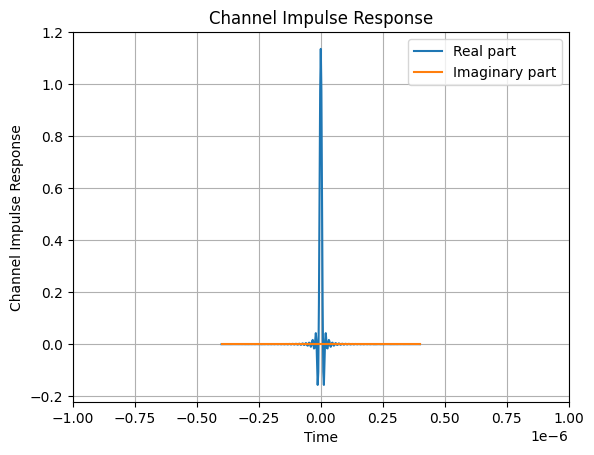

In [26]:
plt.figure()
plt.plot(t_filter, g.real, label='Real part')
plt.plot(t_filter, g.imag, label='Imaginary part')
plt.xlim(-1e-6, 1e-6)
plt.xlabel('Time')
plt.ylabel('Channel Impulse Response')
plt.title('Channel Impulse Response')
plt.grid()
plt.legend()
plt.show()

### Generating random bits ###


In [5]:
def bits_to_qpsk(bits):

    symbols = (2*bits[0::2] - 1) + 1j*(2*bits[1::2] - 1)
    # Normalize the power of the symbols to 1
    symbols /= np.sqrt(2)

    return symbols

def qpsk_to_bits(symbols):

    bits = np.zeros(2*len(symbols), dtype=int)
    bits[0::2] = (np.real(symbols) > 0).astype(int)
    bits[1::2] = (np.imag(symbols) > 0).astype(int)

    return bits



In [6]:
bits = np.random.randint(0, 2, 10)
print("Random bits:", bits)

symbols = bits_to_qpsk(bits)
print("QPSK symbols:", symbols)

bits_estimated = qpsk_to_bits(symbols)
print("Estimated bits:", bits_estimated)

Random bits: [1 0 1 1 1 1 1 0 1 1]
QPSK symbols: [0.70710678-0.70710678j 0.70710678+0.70710678j 0.70710678+0.70710678j
 0.70710678-0.70710678j 0.70710678+0.70710678j]
Estimated bits: [1 0 1 1 1 1 1 0 1 1]


In [30]:
N = 100000
no = 1
sigma_n = 2*no * osr
noise = np.sqrt(sigma_n/2) * (np.random.randn(N) + 1j*np.random.randn(N))
noise_filtered = np.convolve(noise, g_matched, mode='full') / osr 
noise_filtered = noise_filtered[::osr]

noise_power = np.mean(np.abs(noise)**2/osr)
noise_filtered_power = np.mean(np.abs(noise_filtered)**2)
print("Noise power:", noise_power)
print("Filtered noise power:", noise_filtered_power)


Noise power: 2.001768688182576
Filtered noise power: 1.9825528529146468


In [ ]:
snr_db = np.arange(0, 9, 1)
no  = 1 / (2*10**(snr_db/10))

bers = np.zeros(len(snr_db))

for i in range(len(snr_db)):
    sigma_n = 2*no[i] * osr
    for iter in range(100):
        num_bits = 1000
        bits = np.random.randint(0, 2, num_bits)

        # Modulation
        symbols = bits_to_qpsk(bits)
        x = np.zeros(len(symbols)*osr, dtype=complex)
        x[::osr] = symbols

        # Transmission through the channel
        y = np.convolve(x, g, mode='full')

        # Add noise
        noise = np.sqrt(sigma_n/2) * (np.random.randn(len(y)) + 1j*np.random.randn(len(y)))
        y_noisy = y + noise

        # Matched filtering
        y_matched = np.convolve(y_noisy, g_matched, mode='full') / osr

        # Synchronization (assuming perfect synchronization for simplicity)
        y_sync = y_matched[L-1:L-1+len(symbols)*osr:osr]

        # Demodulation
        bits_estimated = qpsk_to_bits(y_sync)

        # BER calculation
        ber = np.mean(bits != bits_estimated)
        bers[i] += ber

    print(f"SNR: {snr_db[i]} dB, BER: {bers[i]/100}")

# Average the BERs over the simulations
bers /= 100
print("BERs:", bers)

SNR: 0 dB, BER: 0.15774000000000005
SNR: 1 dB, BER: 0.13064000000000003
SNR: 2 dB, BER: 0.10459000000000007
SNR: 3 dB, BER: 0.07851999999999999
SNR: 4 dB, BER: 0.0572
SNR: 5 dB, BER: 0.037309999999999975
SNR: 6 dB, BER: 0.022739999999999982
SNR: 7 dB, BER: 0.01319
SNR: 8 dB, BER: 0.005900000000000004
BERs: [0.15774 0.13064 0.10459 0.07852 0.0572  0.03731 0.02274 0.01319 0.0059 ]


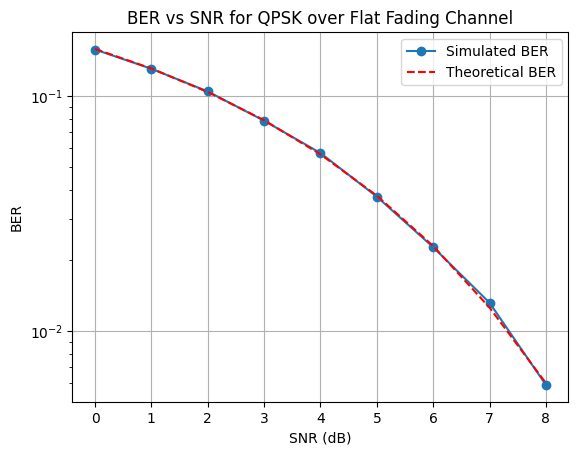

In [11]:
theoretical_ber = np.array([0.5 * math.erfc(np.sqrt(10**(snr_db[i]/10)/2)) for i in range(len(snr_db))])

plt.figure()
plt.semilogy(snr_db, bers, 'o-', label='Simulated BER')
plt.semilogy(snr_db, theoretical_ber, 'r--', label='Theoretical BER')
plt.xlabel('SNR (dB)')
plt.ylabel('BER')
plt.title('BER vs SNR for QPSK over Flat Fading Channel')
plt.grid()
plt.legend()
plt.show()

801 480


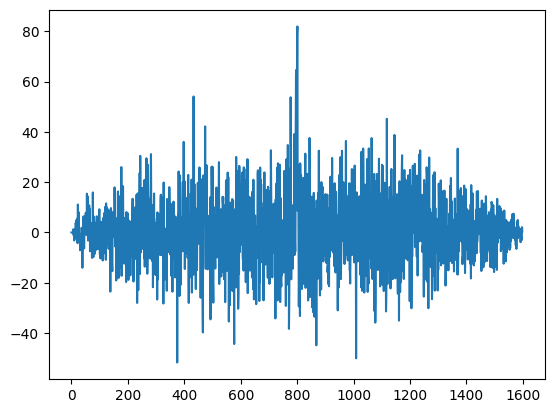

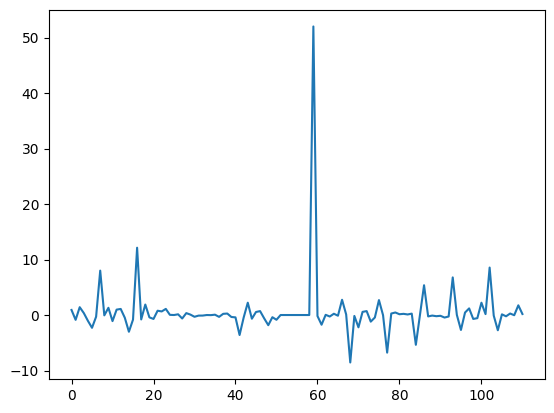

In [74]:
Lcir = 8
pilot_length = 52
pilot_seq = com.zadoff_chu_seq(23, pilot_length)
prefixed_pilot_length = pilot_length + Lcir # Account for cyclic prefix
prefixed_pilot_seq = np.concatenate((pilot_seq[-Lcir:], pilot_seq)) # Add cyclic prefix
x = np.zeros(prefixed_pilot_length*osr, dtype=complex)
x[:prefixed_pilot_length*osr:osr] = prefixed_pilot_seq

y = np.convolve(x, g, mode='full')
sigma_n = 1 * osr
y += np.sqrt(sigma_n/2) * (np.random.randn(len(y)) + 1j*np.random.randn(len(y)))



cross_corr = np.correlate(y, x, mode='full')
print(np.argmax(cross_corr), len(prefixed_pilot_seq)*osr)

plt.figure()
plt.plot(cross_corr)
plt.show()

cross_corr = np.correlate(prefixed_pilot_seq, pilot_seq, mode='full')
plt.figure()
plt.plot(cross_corr)
plt.show()